In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn import svm
from sklearn.pipeline import make_pipeline

In [2]:
df = pd.read_csv("letter-recognition.csv")

In [5]:
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [6]:
df.describe()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


In [7]:
frame = df.groupby("letter")
frame.mean()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
letter,,,,,,,,,,,,,,,,
A,3.337136,6.975919,5.128010,5.178707,2.991128,8.851711,3.631179,2.755387,2.043093,7.802281,2.338403,8.465146,2.771863,6.321926,2.875792,7.468948
B,3.985640,6.962141,5.088773,5.169713,4.596606,7.671018,7.062663,5.366841,5.571802,7.954308,5.506527,6.652742,3.117493,7.919060,6.612272,9.100522
C,4.031250,7.063859,4.701087,5.296196,2.775815,5.437500,7.627717,5.927989,7.177989,8.773098,7.494565,11.947011,1.991848,8.876359,4.080163,8.555707
D,4.023602,7.244720,5.170186,5.288199,4.026087,7.539130,6.806211,5.921739,6.508075,8.166460,5.111801,5.750311,3.365217,7.813665,3.971429,7.628571
E,3.727865,6.944010,4.756510,5.201823,3.679688,5.966146,7.352865,4.223958,7.585938,8.507812,6.242188,10.341146,2.127604,8.298177,6.022135,8.506510
F,3.832258,7.009032,4.898065,5.209032,3.178065,4.913548,10.454194,3.476129,4.886452,11.242581,7.830968,5.723871,1.736774,9.117419,3.321290,6.712258
G,4.086675,6.988357,4.988357,5.282018,3.566624,6.866753,6.586028,5.966365,5.337646,7.429495,6.157827,9.586028,2.833118,8.369987,5.146184,9.216041
H,4.331063,6.844687,5.784741,5.193460,4.253406,7.344687,7.320163,6.702997,4.280654,8.044959,5.899183,7.801090,3.862398,8.047684,3.095368,7.858311
I,2.270199,6.980132,2.631788,5.209272,1.825166,7.458278,7.035762,1.940397,5.973510,9.476821,5.797351,7.649007,0.537748,8.066225,2.141722,7.931126


In [8]:
df

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


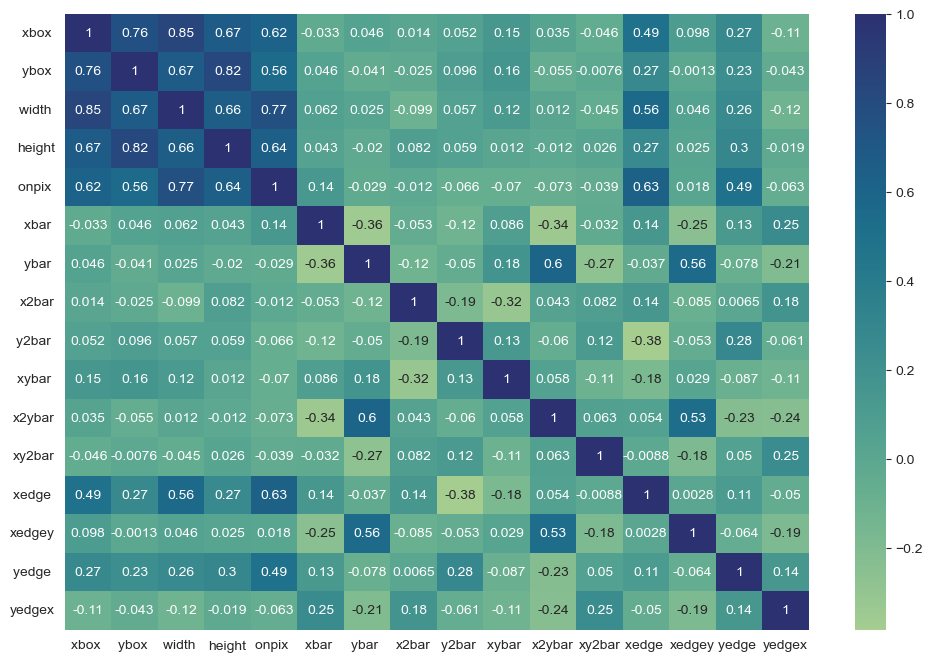

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="crest")
plt.show()

In [10]:
X = l.data.features
y = l.data.targets

In [11]:
X.head()

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [12]:
y.head()

,lettr
0,T
1,I
2,D
3,N
4,G


In [13]:
X["x-box"].sum()

np.int64(80471)

In [14]:
order = np.unique(df["letter"].sort_values())

<Axes: xlabel='letter', ylabel='xbox '>

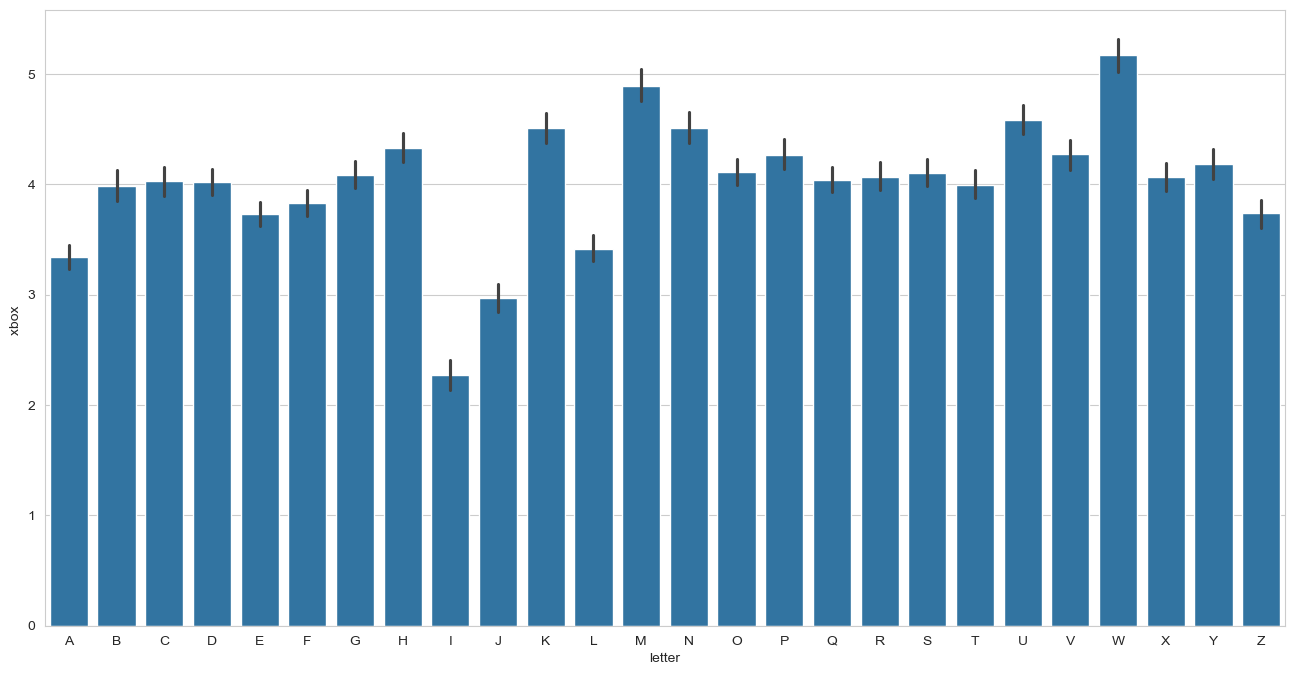

In [15]:
# basic plots: How do various attributes vary with the letters

plt.figure(figsize=(16, 8))
sns.barplot(x="letter", y="xbox ", data=df, order=order, hue_order=order)

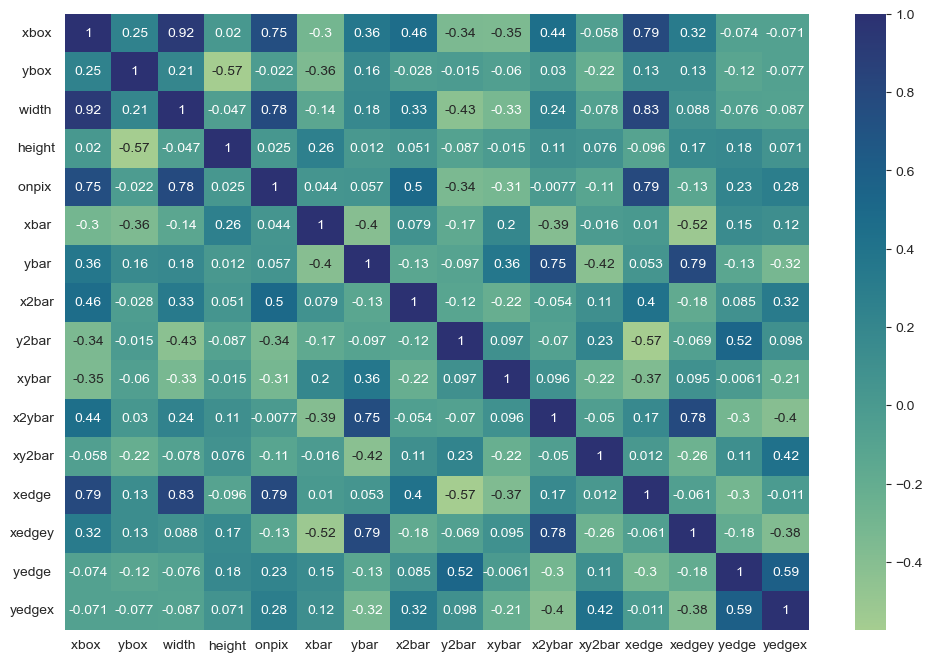

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(frame.mean().corr(), annot=True, cmap="crest")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale, MinMaxScaler, StandardScaler

In [18]:
X_scaled = scale(X)  # X is a csc matrix

In [19]:
X_scaled

array([[-1.0576983 ,  0.29187713, -1.05327668, ..., -0.21908163,
        -1.4381527 ,  0.12291107],
       [ 0.51038497,  1.5023577 , -1.05327668, ..., -0.21908163,
         0.12008142,  1.35944092],
       [-0.01230945,  1.19973756,  0.43590966, ..., -0.8656262 ,
        -0.26947711,  0.74117599],
       ...,
       [ 1.03307939,  0.59449727,  0.43590966, ...,  2.36709667,
        -0.65903564, -2.35014863],
       [-1.0576983 , -1.22122359, -0.55688123, ...,  0.42746295,
         0.50963994,  0.12291107],
       [-0.01230945,  0.59449727,  0.43590966, ..., -0.8656262 ,
        -0.65903564,  0.12291107]])

In [20]:
scaler = MinMaxScaler()
scaler.fit_transform(X)

array([[0.13333333, 0.53333333, 0.2       , ..., 0.53333333, 0.        ,
        0.53333333],
       [0.33333333, 0.8       , 0.2       , ..., 0.53333333, 0.26666667,
        0.66666667],
       [0.26666667, 0.73333333, 0.4       , ..., 0.46666667, 0.2       ,
        0.6       ],
       ...,
       [0.4       , 0.6       , 0.4       , ..., 0.8       , 0.13333333,
        0.26666667],
       [0.13333333, 0.2       , 0.26666667, ..., 0.6       , 0.33333333,
        0.53333333],
       [0.26666667, 0.6       , 0.4       , ..., 0.46666667, 0.13333333,
        0.53333333]])

In [21]:
help(scale)

Help on function scale in module sklearn.preprocessing._data:

scale(X, *, axis=0, with_mean=True, with_std=True, copy=True)
    Standardize a dataset along any axis.

    Center to the mean and component wise scale to unit variance.

    Read more in the :ref:`User Guide <preprocessing_scaler>`.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        The data to center and scale.

    axis : {0, 1}, default=0
        Axis used to compute the means and standard deviations along. If 0,
        independently standardize each feature, otherwise (if 1) standardize
        each sample.

    with_mean : bool, default=True
        If True, center the data before scaling.

    with_std : bool, default=True
        If True, scale the data to unit variance (or equivalently,
        unit standard deviation).

    copy : bool, default=True
        If False, try to avoid a copy and scale in place.
        This is not guaranteed to always work in p

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=101
)  # random-state=> 101

In [23]:
y_train.value_counts()

lettr
U        589
A        580
M        558
D        557
T        557
G        554
V        553
F        550
Y        549
B        548
Q        548
X        543
I        540
P        538
E        534
N        532
O        532
W        530
J        527
L        524
S        520
H        517
R        515
C        506
Z        505
K        494
Name: count, dtype: int64

In [24]:
y_test.value_counts()

lettr
P        265
N        251
D        248
K        245
X        244
R        243
T        239
Y        237
L        237
Q        235
E        234
M        234
C        230
Z        229
S        228
F        225
U        224
W        222
O        221
J        220
G        219
B        218
H        217
I        215
V        211
A        209
Name: count, dtype: int64

## Model Building

In [25]:
warnings.filterwarnings("ignore")

In [26]:
model_linear = svm.SVC(kernel="linear")
model_linear.fit(X_train, y_train)

SVC(kernel='linear')

In [27]:
from sklearn import metrics

In [28]:
y_pred = model_linear.predict(X_test)

In [29]:
print(f"Accuracy of Linear: {metrics.accuracy_score(y_test,y_pred)}")

Accuracy of Linear: 0.8523333333333334


In [30]:
cm = pd.DataFrame(metrics.confusion_matrix(y_test, y_pred), columns=order)
cm

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
0,198,0,0,0,0,0,1,1,0,1,...,0,1,0,1,1,0,0,0,3,0
1,0,188,0,3,0,1,3,3,1,0,...,1,9,3,0,0,1,0,1,0,0
2,1,0,200,0,7,0,12,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1,15,0,210,0,1,2,2,1,0,...,0,5,0,1,0,0,0,0,0,0
4,0,1,3,0,204,2,6,1,0,0,...,2,2,1,2,0,0,0,1,0,3
5,0,0,0,1,1,201,1,2,1,1,...,0,0,3,7,1,0,1,0,1,0
6,0,1,9,4,2,2,167,1,0,1,...,9,1,8,0,0,2,3,0,0,0
7,0,7,3,11,0,4,3,141,0,2,...,4,12,0,0,4,2,0,4,1,0
8,0,0,2,3,0,6,0,0,184,9,...,0,0,3,0,0,0,0,4,0,3
9,2,0,0,3,0,2,0,2,10,187,...,0,1,5,0,1,0,0,0,0,4


In [31]:
cm.describe()

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,...,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,8.846154,9.538462,8.846154,10.038462,9.269231,9.500000,9.115385,7.769231,7.961538,8.230769,...,9.115385,9.576923,8.115385,9.230769,8.615385,7.961538,9.153846,9.307692,8.769231,8.576923
std,38.643698,36.643396,39.048372,40.864146,39.796038,39.203316,32.379409,27.475528,35.980529,36.522111,...,38.599821,36.661885,30.222279,41.806514,41.290267,37.182233,41.435919,41.417648,41.280802,37.893718
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,2.000000,0.000000,0.500000,1.000000,1.500000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,2.750000,3.000000,2.750000,2.000000,5.750000,3.000000,1.000000,1.000000,...,2.750000,2.750000,3.000000,1.000000,1.000000,0.750000,1.000000,1.000000,1.000000,1.750000
max,198.000000,188.000000,200.000000,210.000000,204.000000,201.000000,167.000000,141.000000,184.000000,187.000000,...,198.000000,188.000000,155.000000,214.000000,211.000000,190.000000,212.000000,212.000000,211.000000,194.000000


## First Non Linear Model,

In [32]:
model_rbf = svm.SVC(kernel="rbf")
model_rbf.fit(X_train, y_train)
rbf_y = model_rbf.predict(X_test)

In [33]:
print(f"RBF accuracy score: {metrics.accuracy_score(y_test,rbf_y)}")

RBF accuracy score: 0.9383333333333334


In [34]:
from sklearn.model_selection import KFold, GridSearchCV

# creating a KFold object with 5 splits
folds = KFold(n_splits=5, shuffle=True, random_state=101)

# specify range of hyperparameters
# Set the parameters by cross-validation
hyper_params = [{"gamma": [1e-2, 1e-3, 1e-4], "C": [1, 10, 100, 1000]}]


# specify model
model = svm.SVC(kernel="rbf")

# set up GridSearchCV()
model_cv = GridSearchCV(
    estimator=model,
    param_grid=hyper_params,
    scoring="accuracy",
    cv=folds,
    verbose=1,
    return_train_score=True,
)

# fit the model
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=101, shuffle=True),
             estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000],
                          'gamma': [0.01, 0.001, 0.0001]}],
             return_train_score=True, scoring='accuracy', verbose=1)

In [35]:
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,1.157258,0.008174,1.337104,0.003895,1,0.0100,"{'C': 1, 'gamma': 0.01}",0.826429,0.834643,0.828571,...,0.832714,0.006221,7,0.843929,0.844196,0.847679,0.843571,0.844018,0.844679,0.001514
1,2.476844,0.027831,1.701144,0.004345,1,0.0010,"{'C': 1, 'gamma': 0.001}",0.684643,0.672500,0.682500,...,0.677214,0.005622,10,0.682054,0.683214,0.687768,0.679464,0.686429,0.683786,0.002995
2,4.705254,0.015022,1.775500,0.017433,1,0.0001,"{'C': 1, 'gamma': 0.0001}",0.203929,0.207143,0.206429,...,0.217571,0.014490,12,0.212679,0.217589,0.228393,0.240625,0.240625,0.227982,0.011507
3,0.697074,0.002231,0.877566,0.009475,10,0.0100,"{'C': 10, 'gamma': 0.01}",0.914286,0.908929,0.902500,...,0.911143,0.005585,3,0.929554,0.929464,0.930357,0.928929,0.928125,0.929286,0.000738
4,1.143644,0.006327,1.328362,0.013358,10,0.0010,"{'C': 10, 'gamma': 0.001}",0.806071,0.809643,0.803571,...,0.809000,0.006192,8,0.818125,0.817589,0.819732,0.814375,0.819375,0.817839,0.001902
5,2.450794,0.008961,1.672219,0.002982,10,0.0001,"{'C': 10, 'gamma': 0.0001}",0.684286,0.671071,0.682500,...,0.677000,0.005788,11,0.681964,0.683304,0.687589,0.680089,0.685446,0.683679,0.002622
6,0.726570,0.006473,0.631072,0.011126,100,0.0100,"{'C': 100, 'gamma': 0.01}",0.948571,0.946786,0.941429,...,0.947786,0.003742,2,0.978482,0.977946,0.978393,0.978661,0.978571,0.978411,0.000249
7,0.791472,0.002212,0.937491,0.012534,100,0.0010,"{'C': 100, 'gamma': 0.001}",0.861071,0.866071,0.850000,...,0.863286,0.008189,5,0.879554,0.877143,0.882143,0.875446,0.879286,0.878714,0.002277
8,1.169595,0.010971,1.355492,0.010935,100,0.0001,"{'C': 100, 'gamma': 0.0001}",0.801071,0.806429,0.803929,...,0.805643,0.006008,9,0.813571,0.812679,0.814196,0.810089,0.815357,0.813179,0.001774
9,0.814146,0.008349,0.591889,0.007437,1000,0.0100,"{'C': 1000, 'gamma': 0.01}",0.953571,0.949643,0.948571,...,0.951714,0.002183,1,0.997054,0.997768,0.997411,0.997321,0.997232,0.997357,0.000237


In [36]:
cv_results.param_C.dtype

dtype('int64')

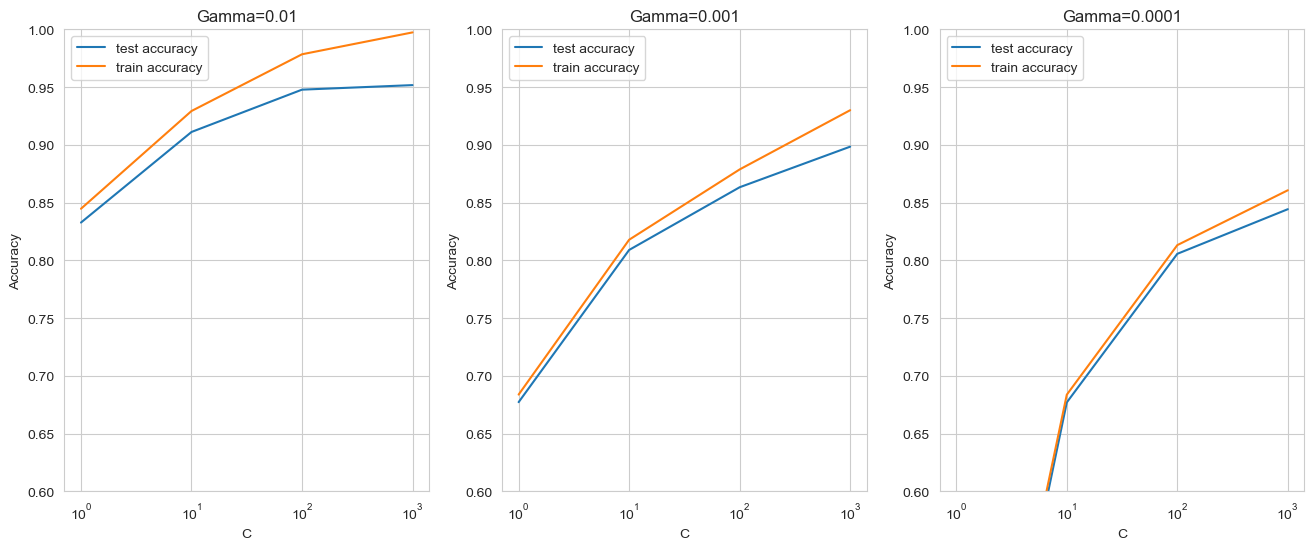

In [37]:
# converting C to numeric type for plotting on x-axis

cv_results["param_C"] = cv_results["param_C"].astype("int")

# # plotting
plt.figure(figsize=(16, 6))

# subplot 1/3
plt.subplot(131)
gamma_01 = cv_results[cv_results["param_gamma"] == 0.01]

plt.plot(gamma_01["param_C"], gamma_01["mean_test_score"])
plt.plot(gamma_01["param_C"], gamma_01["mean_train_score"])
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Gamma=0.01")
plt.ylim([0.60, 1])
plt.legend(["test accuracy", "train accuracy"], loc="upper left")
plt.xscale("log")

# subplot 2/3
plt.subplot(132)
gamma_001 = cv_results[cv_results["param_gamma"] == 0.001]

plt.plot(gamma_001["param_C"], gamma_001["mean_test_score"])
plt.plot(gamma_001["param_C"], gamma_001["mean_train_score"])
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Gamma=0.001")
plt.ylim([0.60, 1])
plt.legend(["test accuracy", "train accuracy"], loc="upper left")
plt.xscale("log")


# subplot 3/3
plt.subplot(133)
gamma_0001 = cv_results[cv_results["param_gamma"] == 0.0001]

plt.plot(gamma_0001["param_C"], gamma_0001["mean_test_score"])
plt.plot(gamma_0001["param_C"], gamma_0001["mean_train_score"])
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Gamma=0.0001")
plt.ylim([0.60, 1])
plt.legend(["test accuracy", "train accuracy"], loc="upper left")
plt.xscale("log")